<a href="https://colab.research.google.com/github/Hala-sala7/chicago-crime-analysis/blob/main/Project3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chicago Crime Data — Time Series Analysis
**Portfolio Project 3 — Part 1**

This notebook prepares the Chicago crime dataset (2001–present) for time series
analysis and answers stakeholder questions for a local newspaper reporter
about crime trends in Chicago.

**Original source:** Chicago Data Portal — Crimes 2001 to Present.

## 1. Imports & Setup
Import the libraries used throughout the notebook and configure plotting defaults.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile, glob, os
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
%matplotlib inline

## 2. Mount Google Drive
Connect Google Drive so we can access the zipped dataset stored there.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Locate the Zip File
Search Drive for the dataset zip and print its full path.

In [5]:
glob.glob('/content/drive/MyDrive/**/*.zip', recursive=True)

['/content/drive/MyDrive/assignment.zip',
 '/content/drive/MyDrive/Chicago_Crime_2001-2022.zip']

## 4. Extract the Data
Unzip the dataset (one CSV per year) into a local `/content/Data` folder.
Note: this folder is temporary in Colab — re-run this cell after a restart.

In [9]:
zip_path = "/content/drive/MyDrive/Chicago_Crime_2001-2022.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/content/Data')

print("Done. Folder contents:")
print(os.listdir('/content/Data'))

Done. Folder contents:
['Data']


## 5. Locate the CSV Files
The dataset is split into one CSV per year. Find them all (recursively).
The README file is automatically ignored because we only match `*.csv`.

In [10]:
csv_files = sorted(glob.glob('/content/Data/**/*.csv', recursive=True))
print(f"Found {len(csv_files)} files:")
for f in csv_files:
    print("  -", f)

Found 22 files:
  - /content/Data/Data/Chicago-Crime_2001.csv
  - /content/Data/Data/Chicago-Crime_2002.csv
  - /content/Data/Data/Chicago-Crime_2003.csv
  - /content/Data/Data/Chicago-Crime_2004.csv
  - /content/Data/Data/Chicago-Crime_2005.csv
  - /content/Data/Data/Chicago-Crime_2006.csv
  - /content/Data/Data/Chicago-Crime_2007.csv
  - /content/Data/Data/Chicago-Crime_2008.csv
  - /content/Data/Data/Chicago-Crime_2009.csv
  - /content/Data/Data/Chicago-Crime_2010.csv
  - /content/Data/Data/Chicago-Crime_2011.csv
  - /content/Data/Data/Chicago-Crime_2012.csv
  - /content/Data/Data/Chicago-Crime_2013.csv
  - /content/Data/Data/Chicago-Crime_2014.csv
  - /content/Data/Data/Chicago-Crime_2015.csv
  - /content/Data/Data/Chicago-Crime_2016.csv
  - /content/Data/Data/Chicago-Crime_2017.csv
  - /content/Data/Data/Chicago-Crime_2018.csv
  - /content/Data/Data/Chicago-Crime_2019.csv
  - /content/Data/Data/Chicago-Crime_2020.csv
  - /content/Data/Data/Chicago-Crime_2021.csv
  - /content/Data/

## 6. Inspect the Columns
Read just the first file to confirm the column names (especially the date column)
before loading everything.

In [11]:
sample = pd.read_csv(csv_files[0], nrows=5)
print(sample.columns.tolist())
sample

['ID', 'Date', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Latitude', 'Longitude']


,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
0,1326041,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE,False,False,1624,16.0,NaN,41.957850,-87.749185
1,1319931,01/01/2001 01:00:00 PM,BATTERY,SIMPLE,RESIDENCE,False,True,825,8.0,NaN,41.783892,-87.684841
2,1324743,01/01/2001 01:00:00 PM,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313,3.0,NaN,41.780412,-87.611970
3,1310717,01/01/2001 01:00:00 AM,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424,24.0,NaN,42.012391,-87.678032
4,1318099,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214,2.0,NaN,41.819538,-87.620020


## 7. Combine All Years into One DataFrame
Read every yearly file (keeping only the columns we need) and concatenate them.

In [12]:
use_cols = ['Date', 'Primary Type', 'Description', 'District', 'Arrest', 'Domestic']

df = pd.concat(
    [pd.read_csv(f, usecols=use_cols) for f in csv_files],
    ignore_index=True
)
print("Shape:", df.shape)
df.head()

Shape: (7713109, 6)


,Date,Primary Type,Description,Arrest,Domestic,District
0,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,False,False,16.0
1,01/01/2001 01:00:00 PM,BATTERY,SIMPLE,False,True,8.0
2,01/01/2001 01:00:00 PM,GAMBLING,ILLEGAL ILL LOTTERY,True,False,3.0
3,01/01/2001 01:00:00 AM,CRIMINAL DAMAGE,TO VEHICLE,False,False,24.0
4,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,False,True,2.0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7713109 entries, 0 to 7713108
Data columns (total 6 columns):
 #   Column        Dtype  
---  ------        -----  
 0   Date          object 
 1   Primary Type  object 
 2   Description   object 
 3   Arrest        bool   
 4   Domestic      bool   
 5   District      float64
dtypes: bool(2), float64(1), object(3)
memory usage: 250.1+ MB


## 8. Convert the Date Column to Datetime
Convert the `Date` text column to a proper datetime type for time series analysis.

In [14]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p')
df['Date'].head()

,Date
0,2001-01-01 01:00:00
1,2001-01-01 13:00:00
2,2001-01-01 13:00:00
3,2001-01-01 01:00:00
4,2001-01-01 01:00:00


## 9. Set Datetime Index
Set `Date` as the index and sort chronologically.
**(Form 1 of the data: each row = 1 crime, datetime index.)**

In [15]:
df = df.set_index('Date').sort_index()
df.head()

,Primary Type,Description,Arrest,Domestic,District
Date,,,,,
2001-01-01,THEFT,FINANCIAL ID THEFT: OVER $300,False,False,22.0
2001-01-01,THEFT,AGG: FINANCIAL ID THEFT,False,False,8.0
2001-01-01,OFFENSE INVOLVING CHILDREN,SEX ASSLT OF CHILD BY FAM MBR,False,False,2.0
2001-01-01,THEFT,FINANCIAL ID THEFT: OVER $300,False,False,9.0
2001-01-01,SEX OFFENSE,AGG CRIMINAL SEXUAL ABUSE,False,False,10.0


## 10. Clean the Data
Check missing values and drop rows missing `District`
(needed later for the district comparison).

In [17]:
df.isna().sum()

,0
Primary Type,0
Description,0
Arrest,0
Domestic,0
District,47


In [18]:
print("Missing District:", df['District'].isna().sum())
print("Percentage:", round(df['District'].isna().mean() * 100, 4), "%")

Missing District: 47
Percentage: 0.0006 %


Only **47 rows** (0.0006% of the data) are missing a `District`.
Since this is a negligible fraction and `District` is a categorical
identifier (imputing a fake district would distort the district analysis),
we drop these rows.

In [19]:
df = df.dropna(subset=['District'])
df['District'] = df['District'].astype(int)
print("Shape after cleaning:", df.shape)

Shape after cleaning: (7713062, 5)


## 11. Resampled Daily Crime Counts
Create the second form of the data: each row = 1 day with the total number
of crimes. Used for trend & seasonality analysis.

In [20]:
daily_counts = df.resample('D').size().rename('Crime_Count')
daily_counts.head()

,Crime_Count
Date,
2001-01-01,1825
2001-01-02,1143
2001-01-03,1151
2001-01-04,1166
2001-01-05,1267


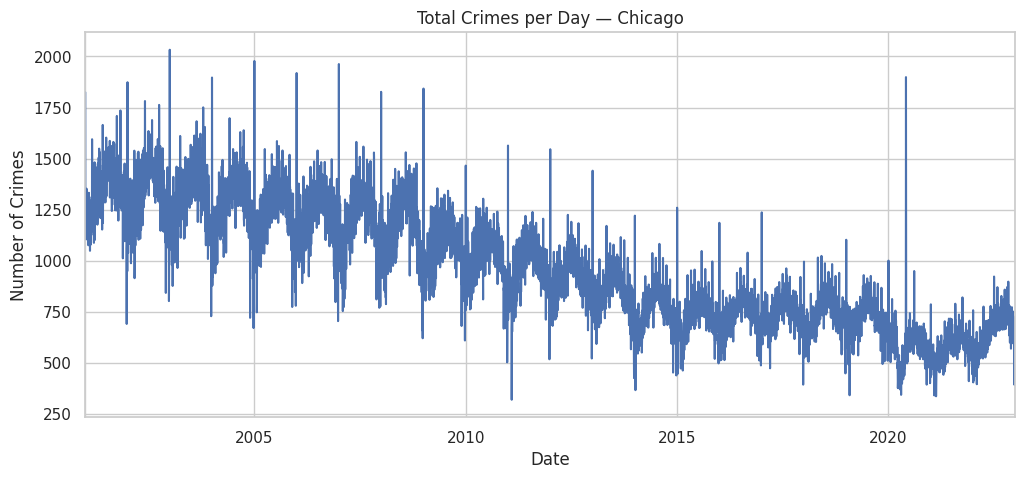

In [21]:
daily_counts.plot(title='Total Crimes per Day — Chicago')
plt.ylabel('Number of Crimes')
plt.show()

### Observations — Daily Crime Counts (2001–2022)

- **Clear downward trend:** Daily crimes fell from ~1,200–1,500/day in the early
  2000s to ~600–800/day by the early 2020s — almost a 50% decline over two decades.
- **Strong seasonality:** A repeating yearly wave is visible (crime peaks in summer,
  dips in winter), which we will confirm later with seasonal decomposition.
- **Sharp spikes on Jan 1st:** The recurring tall spikes (e.g. the first point = 1,825)
  fall on January 1st. This is a known data artifact — crimes with an unknown exact
  date are logged as Jan 1st, inflating that day.
- **2020 dip:** The unusually low values around 2020 line up with COVID-19 lockdowns.

## 12. Feature Engineering
Add a `Holiday` column (holiday name if the date is a US holiday, else NaN)
plus helper time columns (Year, Month, Hour, Day name) for the analysis section.

In [22]:
!pip install holidays -q
import holidays

years = df.index.year.unique().tolist()
us_holidays = holidays.US(years=years)

df['Holiday']    = df.index.normalize().map(lambda d: us_holidays.get(d))
df['Year']       = df.index.year
df['Month']      = df.index.month
df['Month_Name'] = df.index.month_name()
df['Hour']       = df.index.hour
df['Day_Name']   = df.index.day_name()

df.head()

,Primary Type,Description,Arrest,Domestic,District,Holiday,Year,Month,Month_Name,Hour,Day_Name
Date,,,,,,,,,,,
2001-01-01,THEFT,FINANCIAL ID THEFT: OVER $300,False,False,22,New Year's Day,2001,1,January,0,Monday
2001-01-01,THEFT,AGG: FINANCIAL ID THEFT,False,False,8,New Year's Day,2001,1,January,0,Monday
2001-01-01,OFFENSE INVOLVING CHILDREN,SEX ASSLT OF CHILD BY FAM MBR,False,False,2,New Year's Day,2001,1,January,0,Monday
2001-01-01,THEFT,FINANCIAL ID THEFT: OVER $300,False,False,9,New Year's Day,2001,1,January,0,Monday
2001-01-01,SEX OFFENSE,AGG CRIMINAL SEXUAL ABUSE,False,False,10,New Year's Day,2001,1,January,0,Monday


# Topic 2 — Crimes Across the Years

**Stakeholder questions:**
1. Is the total number of crimes increasing or decreasing across the years?
2. Are there individual crimes doing the opposite of the overall trend?

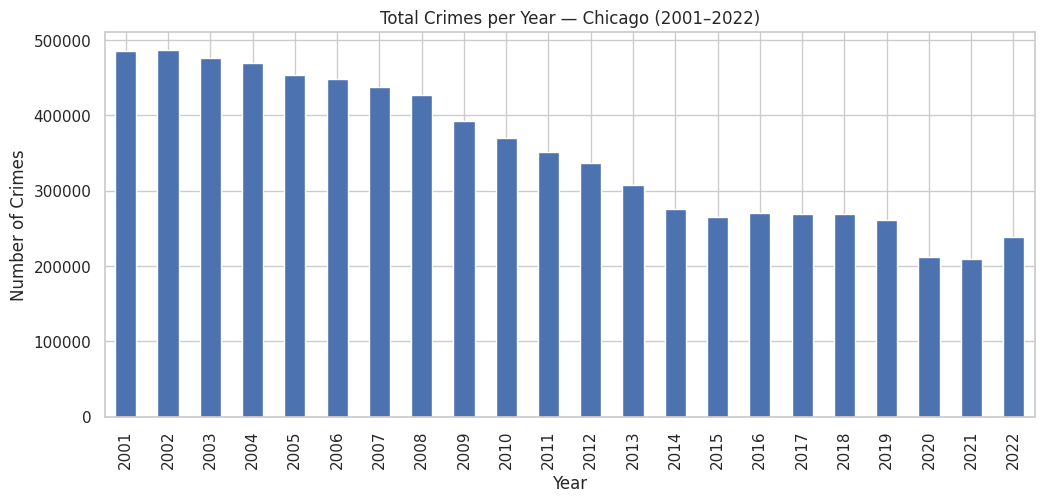

,count
Year,
2001,485886
2002,486807
2003,475985
2004,469420
2005,453772
2006,448178
2007,437085
2008,427143
2009,392827


In [23]:
yearly = df['Year'].value_counts().sort_index()

yearly.plot(kind='bar', title='Total Crimes per Year — Chicago (2001–2022)')
plt.ylabel('Number of Crimes')
plt.xlabel('Year')
plt.show()

yearly

### Answer (Q1): Is total crime increasing or decreasing?

**Total crime is clearly decreasing across the years.**

- 2001: **485,886** crimes → 2022: **238,858** crimes
- A decline of about **51%** over the two decades.
- The drop is steady from 2001–2014, then levels off around 260,000–270,000/year.
- **2020 (212,194)** and **2021 (208,824)** are the two lowest years, lining up
  with the COVID-19 pandemic, followed by a partial rebound in 2022.

In [24]:
# Crimes per type per year
type_year = df.groupby(['Year', 'Primary Type']).size().unstack(fill_value=0)

# Focus on reasonably common crimes (avoid noise from rare types)
common = type_year.columns[type_year.sum() > 5000]
ty = type_year[common]

In [25]:
# % change: average of last 3 years vs first 3 years
early  = ty.iloc[:3].mean()
recent = ty.iloc[-3:].mean()
pct_change = ((recent - early) / early * 100).round(1).sort_values(ascending=False)

In [26]:
print("Crimes that INCREASED the most (against the overall trend):")
print(pct_change.head(5))
print("\nCrimes that DECREASED the most:")
print(pct_change.tail(5))

Crimes that INCREASED the most (against the overall trend):
Primary Type
CRIMINAL SEXUAL ASSAULT             4254.6
WEAPONS VIOLATION                    105.0
DECEPTIVE PRACTICE                    23.7
HOMICIDE                              20.8
INTERFERENCE WITH PUBLIC OFFICER      15.6
dtype: float64

Crimes that DECREASED the most:
Primary Type
LIQUOR LAW VIOLATION   -87.8
NARCOTICS              -88.8
PROSTITUTION           -96.5
GAMBLING               -98.4
CRIM SEXUAL ASSAULT    -98.5
dtype: float64


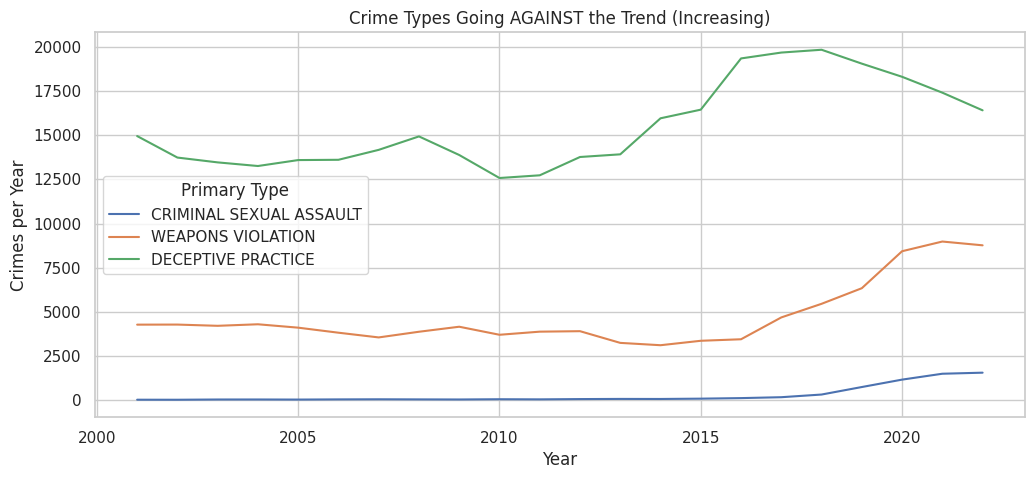

In [27]:
increasing = pct_change.head(3).index
ty[increasing].plot(title='Crime Types Going AGAINST the Trend (Increasing)')
plt.ylabel('Crimes per Year')
plt.show()

### Answer (Q2): Are there crimes going against the overall trend?

**Yes.** While total crime fell ~51%, several crime types **increased**,
going against the overall downward trend:

| Crime Type | % Change (first 3 yrs → last 3 yrs) |
|---|---|
| Criminal Sexual Assault | +4254.6% ⚠️ |
| Weapons Violation | +105.0% |
| Deceptive Practice | +23.7% |
| Homicide | +20.8% |
| Interference with Public Officer | +15.6% |

**The most meaningful increase is Weapons Violation (+105%)** — it more than doubled,
rising from ~4,000/year to ~9,000/year (clearly visible in the plot).

⚠️ **Note on Criminal Sexual Assault (+4254.6%):** this huge percentage is misleading.
The category started near zero in the early 2000s, so even a small absolute increase
produces an enormous percentage. In raw numbers it remains one of the smaller categories.

**For contrast, the crimes that fell the most were:** Criminal Sexual Abuse (−98.5%),
Gambling (−98.4%), Prostitution (−96.5%), Narcotics

# Topic 3 — AM vs PM Rush Hour

**Definitions used:**
- **AM rush hour:** crimes between 7 AM – 10 AM (hours 7, 8, 9)
- **PM rush hour:** crimes between 4 PM – 7 PM (hours 16, 17, 18)

**Stakeholder questions:**
1. What are the top 5 most common crimes during AM rush? During PM rush?
2. Are Motor Vehicle Thefts more common during AM or PM rush?

### Split the data into AM and PM rush-hour windows

In [28]:
am_rush = df[df['Hour'].isin([7, 8, 9])]
pm_rush = df[df['Hour'].isin([16, 17, 18])]

print("Total crimes during AM rush (7–10 AM):", len(am_rush))
print("Total crimes during PM rush (4–7 PM):", len(pm_rush))

Total crimes during AM rush (7–10 AM): 770650
Total crimes during PM rush (4–7 PM): 1206345


### Observation: Overall rush-hour volume

PM rush hour (4–7 PM) sees far more crime than AM rush hour (7–10 AM):
- **AM rush (7–10 AM):** 770,650 crimes
- **PM rush (4–7 PM):** 1,206,345 crimes

PM rush has about **57% more crime** than AM rush — crime concentrates more
in the late-afternoon/evening commute than the morning.

### Q1: Top 5 most common crimes in each rush-hour window

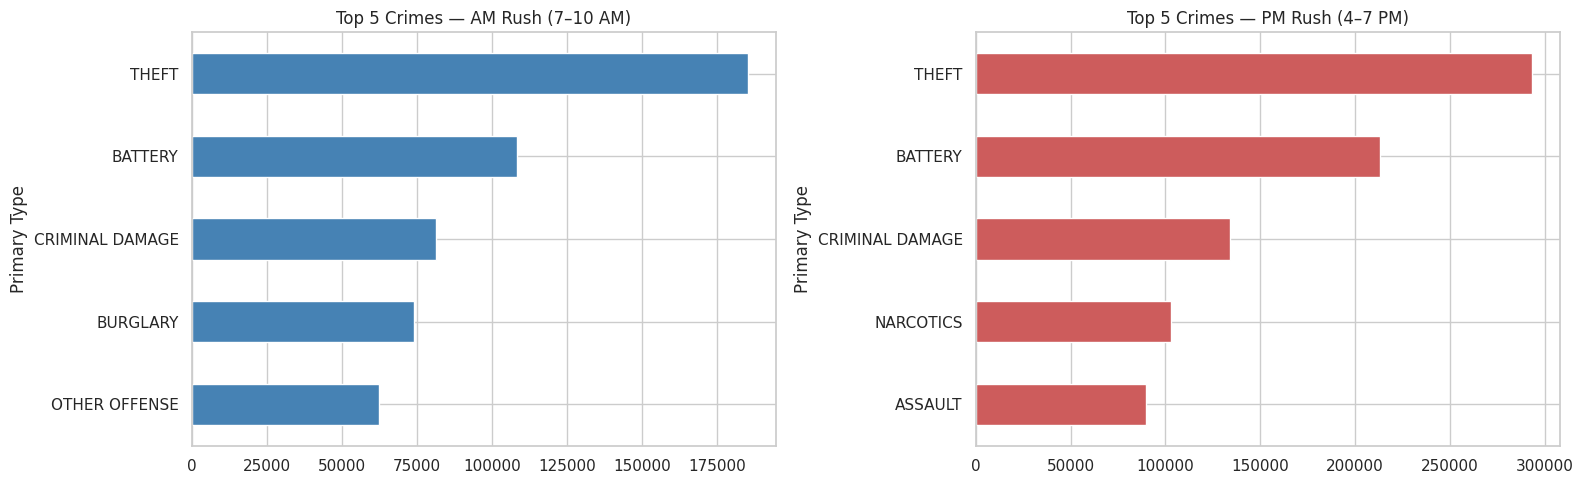

AM Top 5:
 Primary Type
THEFT              185239
BATTERY            108199
CRIMINAL DAMAGE     81281
BURGLARY            73998
OTHER OFFENSE       62453
Name: count, dtype: int64 

PM Top 5:
 Primary Type
THEFT              293513
BATTERY            213002
CRIMINAL DAMAGE    134099
NARCOTICS          103031
ASSAULT             89600
Name: count, dtype: int64


In [29]:
am_top5 = am_rush['Primary Type'].value_counts().head(5)
pm_top5 = pm_rush['Primary Type'].value_counts().head(5)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
am_top5.sort_values().plot(kind='barh', ax=axes[0],
    title='Top 5 Crimes — AM Rush (7–10 AM)', color='steelblue')
pm_top5.sort_values().plot(kind='barh', ax=axes[1],
    title='Top 5 Crimes — PM Rush (4–7 PM)', color='indianred')
plt.tight_layout()
plt.show()

print("AM Top 5:\n", am_top5, "\n")
print("PM Top 5:\n", pm_top5)

### Answer (Q1): Top 5 most common crimes in each rush-hour window

**AM Rush (7–10 AM):**
1. Theft — 185,239
2. Battery — 108,199
3. Criminal Damage — 81,281
4. Burglary — 73,998
5. Other Offense — 62,453

**PM Rush (4–7 PM):**
1. Theft — 293,513
2. Battery — 213,002
3. Criminal Damage — 134,099
4. Narcotics — 103,031
5. Assault — 89,600

**Theft, Battery, and Criminal Damage are the top 3 in both windows.**
The difference is in the 4th–5th spots: AM rush features **Burglary** and
**Other Offense**, while PM rush features **Narcotics** and **Assault** —
crimes that skew toward the evening. Every category also has a much higher
count in the PM window, consistent with PM rush having ~57% more total crime.

### Q2: Are Motor Vehicle Thefts more common in AM or PM rush?

Motor Vehicle Theft — AM rush: 41578
Motor Vehicle Theft — PM rush: 53714


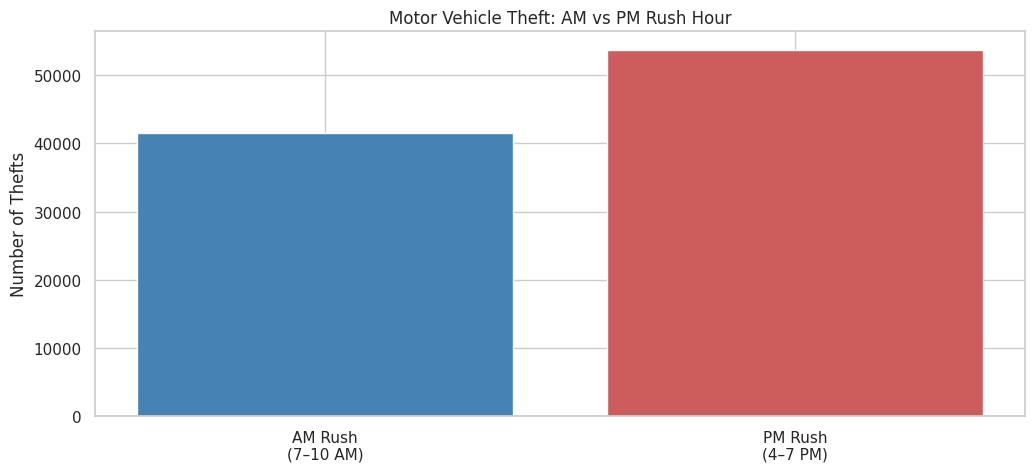

In [30]:
mvt_am = (am_rush['Primary Type'] == 'MOTOR VEHICLE THEFT').sum()
mvt_pm = (pm_rush['Primary Type'] == 'MOTOR VEHICLE THEFT').sum()

print("Motor Vehicle Theft — AM rush:", mvt_am)
print("Motor Vehicle Theft — PM rush:", mvt_pm)

plt.bar(['AM Rush\n(7–10 AM)', 'PM Rush\n(4–7 PM)'], [mvt_am, mvt_pm],
        color=['steelblue', 'indianred'])
plt.title('Motor Vehicle Theft: AM vs PM Rush Hour')
plt.ylabel('Number of Thefts')
plt.show()

### Answer (Q2): Are Motor Vehicle Thefts more common in AM or PM rush?

**Motor Vehicle Thefts are more common during PM rush hour (4–7 PM).**

- AM rush (7–10 AM): **41,578** thefts
- PM rush (4–7 PM): **53,714** thefts

PM rush sees about **29% more** motor vehicle thefts than AM rush — consistent
with the overall pattern that crime concentrates more in the late-afternoon/evening
commute than the morning.

# Topic 6 — Seasonality

We use `statsmodels.tsa.seasonal.seasonal_decompose` to break the time series
into **trend + seasonal + residual** components and identify recurring cycles.
We examine two cycles: a **yearly cycle** (monthly data) and a **weekly cycle** (daily data).

### Yearly cycle — monthly resampled data

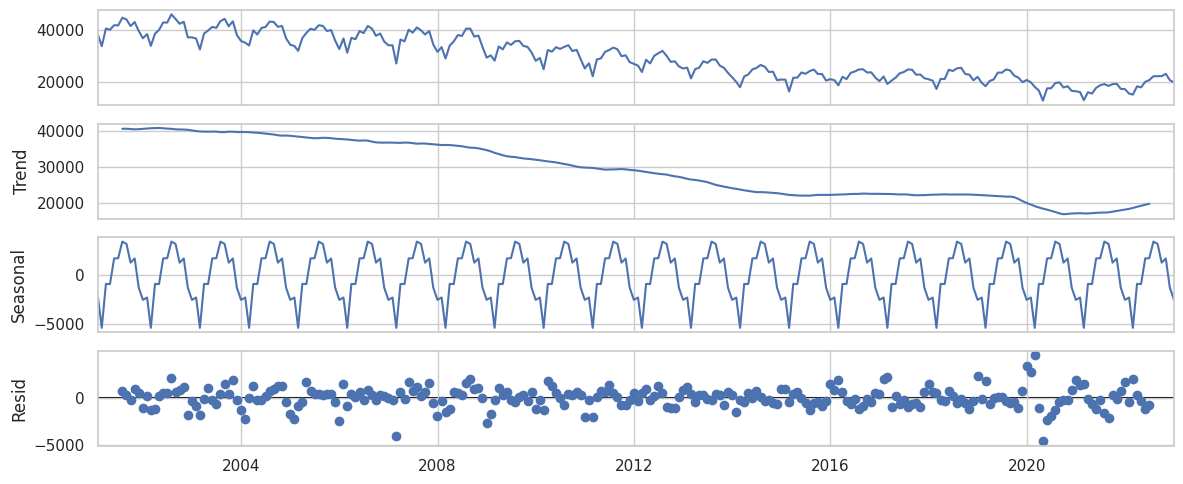

Yearly cycle length: 12 months (1 year)
Magnitude (max - min of seasonal component): 8898


In [31]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Monthly total crimes
monthly = df.resample('ME').size()

result_year = seasonal_decompose(monthly, model='additive', period=12)
result_year.plot()
plt.tight_layout()
plt.show()

seasonal_year = result_year.seasonal
print("Yearly cycle length: 12 months (1 year)")
print("Magnitude (max - min of seasonal component):",
      round(seasonal_year.max() - seasonal_year.min()))

### Answer: Yearly Cycle

The decomposition reveals a clear, repeating **yearly cycle**:

- **Trend** (2nd panel): confirms the long-term decline from ~40,000 to ~20,000
  crimes/month, with the COVID-19 dip around 2020 and a slight rebound after.
- **Seasonal** (3rd panel): a consistent 12-month wave repeats every year —
  crime **peaks in summer** (around July) and **dips in winter** (around February).
- **Residual** (4th panel): mostly small and random, meaning trend + seasonality
  explain most of the variation in the data.

**Cycle length:** 12 months (1 year)
**Magnitude:** ~**8,898** crimes/month between the seasonal low (winter) and
high (summer).

### Weekly cycle — daily data, zoomed in to read the pattern

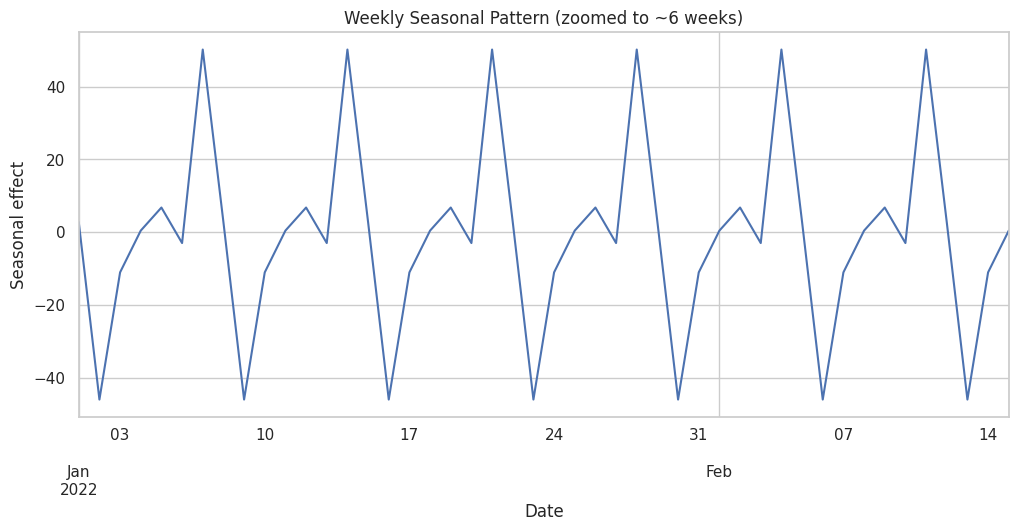

Weekly cycle length: 7 days (1 week)
Magnitude (max - min of seasonal component): 96


In [32]:
result_week = seasonal_decompose(daily_counts, model='additive', period=7)

# Zoom into ~6 weeks so the weekly pattern is readable
result_week.seasonal['2022-01-01':'2022-02-15'].plot(
    title='Weekly Seasonal Pattern (zoomed to ~6 weeks)')
plt.ylabel('Seasonal effect')
plt.show()

seasonal_week = result_week.seasonal
print("Weekly cycle length: 7 days (1 week)")
print("Magnitude (max - min of seasonal component):",
      round(seasonal_week.max() - seasonal_week.min()))

### Answer: Weekly Cycle

The daily data also contains a clear, repeating **weekly cycle** (7-day pattern):

- The seasonal effect swings from about **−45 to +50** crimes/day, repeating
  every 7 days.
- Crime is **highest on weekends (especially Friday/Saturday)** and
  **lowest mid-week (around Sunday/Monday)**.

**Cycle length:** 7 days (1 week)
**Magnitude:** ~**96** crimes/day between the weekly low and high (≈ +50 to −45).

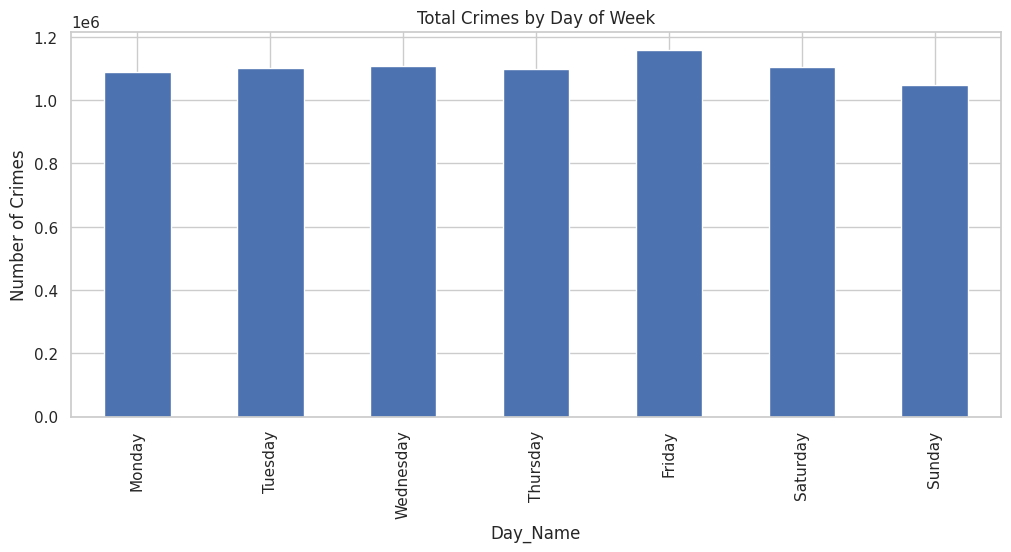

Day with MOST crimes: Friday -> 1159374
Day with LEAST crimes: Sunday -> 1048161


In [33]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
by_day = df['Day_Name'].value_counts().reindex(day_order)

by_day.plot(kind='bar', title='Total Crimes by Day of Week')
plt.ylabel('Number of Crimes')
plt.show()

print("Day with MOST crimes:", by_day.idxmax(), "->", by_day.max())
print("Day with LEAST crimes:", by_day.idxmin(), "->", by_day.min())

### Answer: Weekly Cycle

The daily data contains a clear, repeating **weekly cycle** (7-day pattern),
confirmed by both the seasonal decomposition and the day-of-week totals:

- Crime is **highest on Friday** (1,159,374 total) and **lowest on Sunday**
  (1,048,161 total).
- The seasonal effect repeats every 7 days, swinging by ~96 crimes/day across the week.

**Cycle length:** 7 days (1 week)
**Magnitude:** ~96 crimes/day between the weekly low (Sunday) and high (Friday).

# Project 3 — Part 2: Forecasting Chicago Crime
We forecast monthly crime counts 6 months into the future for **Theft** and
**Battery**, to help Chicago law enforcement allocate resources. For each crime we
build a manual SARIMA model and an auto_arima model, compare them, and forecast.

## 1. Imports for Forecasting

In [34]:
!pip install pmdarima -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_squared_error

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.4 MB/s eta 0:00:00


## 2. Build Monthly Crime-Count Time Series
Transform the data into a monthly count for each selected crime using `.size()`.

In [35]:
theft   = df[df['Primary Type'] == 'THEFT'].resample('MS').size()
battery = df[df['Primary Type'] == 'BATTERY'].resample('MS').size()

print("Theft series:", theft.shape)
print("Battery series:", battery.shape)
theft.tail()

Theft series: (264,)
Battery series: (264,)


,0
Date,
2022-08-01,5244
2022-09-01,5117
2022-10-01,5242
2022-11-01,4717
2022-12-01,4413


## 3. Check Null Values & Final Month
`.size()` produces no nulls, but we verify. We also check the last month is
complete (a partial final month would distort the forecast).

In [36]:
print("Theft nulls:",   theft.isna().sum())
print("Battery nulls:", battery.isna().sum())
print("\nLast 3 months (Theft):")
print(theft.tail(3))

Theft nulls: 0
Battery nulls: 0

Last 3 months (Theft):
Date
2022-10-01    5242
2022-11-01    4717
2022-12-01    4413
Freq: MS, dtype: int64


In [37]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.tsa.api as tsa
from pmdarima.model_selection import train_test_split
from pmdarima.arima.utils import ndiffs

# Set wide fig size for plots
plt.rcParams['figure.figsize'] = (12, 3)

In [38]:
def plot_forecast(ts_train, ts_test, forecast_df, n_train_lags=None,
                  figsize=(10, 4), title='Comparing Forecast vs. True Data'):
    ### Plot training data, and forecast (with upper/lower ci)
    fig, ax = plt.subplots(figsize=figsize)

    # setting the number of train lags to plot if not specified
    if n_train_lags == None:
        n_train_lags = len(ts_train)

    # Plotting Training and test data
    ts_train.iloc[-n_train_lags:].plot(ax=ax, label="train")
    ts_test.plot(label="test", ax=ax)

    # Plot forecast
    forecast_df['mean'].plot(ax=ax, color='green', label='forecast')

    # Add the shaded confidence interval
    ax.fill_between(forecast_df.index,
                    forecast_df['mean_ci_lower'],
                    forecast_df['mean_ci_upper'],
                    color='green', alpha=0.3, lw=2)

    # set the title and add legend
    ax.set_title(title)
    ax.legend();

    return fig, ax

In [39]:
# Custom function for Ad Fuller Test
def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs):  # kwargs for adfuller()
    # Saving each output
    (test_stat, pval, nlags, nobs, crit_vals_d, icbest) = tsa.adfuller(ts, **kwargs)
    # Converting output to a dictionary with the interpretation of p
    adfuller_results = {'Test Statistic': test_stat,
                        '# of Lags Used': nlags,
                        '# of Observations': nobs,
                        'p-value': round(pval, 6),
                        'alpha': alpha,
                        'sig/stationary?': pval < alpha}
    return pd.DataFrame(adfuller_results, index=[label])

In [53]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             mean_absolute_percentage_error)

def regression_metrics_ts(ts_true, ts_pred, label="", verbose=True,
                          output_dict=False,):
    # Get metrics
    mae = mean_absolute_error(ts_true, ts_pred)
    mse = mean_squared_error(ts_true, ts_pred)
    rmse = np.sqrt(mean_squared_error(ts_true, ts_pred))
    r_squared = r2_score(ts_true, ts_pred)
    mae_perc = mean_absolute_percentage_error(ts_true, ts_pred) * 100

    if verbose == True:
        # Print Result with label
        header = "---" * 20
        print(header, f"Regression Metrics: {label}", header, sep="\n")
        print(f"- MAE = {mae:,.3f}")
        print(f"- MSE = {mse:,.3f}")
        print(f"- RMSE = {rmse:,.3f}")
        print(f"- R^2 = {r_squared:,.3f}")
        print(f"- MAPE = {mae_perc:,.2f}%")

    if output_dict == True:
        metrics = {
            "Label": label,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R^2": r_squared,
            "MAPE(%)": mae_perc,
        }
        return metrics

In [41]:
def get_sig_lags(ts, type='ACF', nlags=None, alpha=0.5):

    if type == 'ACF':
        # Running the function used by plot_acf
        corr_values, conf_int = tsa.stattools.acf(ts, alpha=alpha, nlags=nlags)

    elif type == 'PACF':
        corr_values, conf_int = tsa.stattools.pacf(ts, alpha=alpha, nlags=nlags)

    else:
        raise Exception("type must be either 'ACF' or 'PACF'")

    # Determine lags
    lags = range(len(corr_values))

    # Create a centered version of the acf_df
    corr_df = pd.DataFrame({type: corr_values,
                            'Lags': lags,
                            'lower ci': conf_int[:, 0] - corr_values,  # subtract acf from lower ci to center
                            'upper ci': conf_int[:, 1] - corr_values,  # subtract acf to upper ci to center
                            })
    corr_df = corr_df.set_index("Lags")

    # Getting filter for sig lags
    filter_sig_lags = (corr_df[type] < corr_df['lower ci']) | (corr_df[type] > corr_df['upper ci'])

    # Get lag #'s
    sig_lags = corr_df.index[filter_sig_lags]
    sig_lags = sig_lags[sig_lags != 0]

    return sig_lags

In [42]:
def plot_acf_pacf(ts, nlags=40, figsize=(10, 5),
                  annotate_sig=False, alpha=.05,
                  acf_kws={}, pacf_kws={},
                  annotate_seas=False, m=None,
                  seas_color='black'):

    fig, axes = plt.subplots(nrows=2, figsize=figsize)

    # Sig lags line style
    sig_vline_kwargs = dict(ls=':', lw=1, zorder=0, color='red')

    # ACF
    tsa.graphics.plot_acf(ts, ax=axes[0], lags=nlags, **acf_kws)

    ## Annotating sig acf lags
    if annotate_sig == True:
        sig_acf_lags = get_sig_lags(ts, nlags=nlags, alpha=alpha, type='ACF')
        for lag in sig_acf_lags:
            axes[0].axvline(lag, label='sig', **sig_vline_kwargs)

    # PACF
    tsa.graphics.plot_pacf(ts, ax=axes[1], lags=nlags, **pacf_kws)

    ## Annotating sig pacf lags
    if annotate_sig == True:
        ## ANNOTATING SIG LAGS
        sig_pacf_lags = get_sig_lags(ts, nlags=nlags, alpha=alpha, type='PACF')
        for lag in sig_pacf_lags:
            axes[1].axvline(lag, label='sig', **sig_vline_kwargs)

    ### ANNOTATE SEASONS
    if annotate_seas == True:
        # Ensure m was defined
        if m is None:
            raise Exception("Must define value of m if annotate_seas=True.")

        ## Calculate number of complete seasons to annotate
        n_seasons = nlags // m

        # Seasonal Lines style
        seas_vline_kwargs = dict(ls='--', lw=1, alpha=.7, color=seas_color, zorder=-1)

        ## for each season, add a line
        for i in range(1, n_seasons + 1):
            axes[0].axvline(m * i, **seas_vline_kwargs, label="season")
            axes[1].axvline(m * i, **seas_vline_kwargs, label="season")

    fig.tight_layout()
    return fig

## Decompose to Detect Seasonality — Theft
Check for a yearly cycle. A clear repeating pattern → use a seasonal model (SARIMA, m=12).

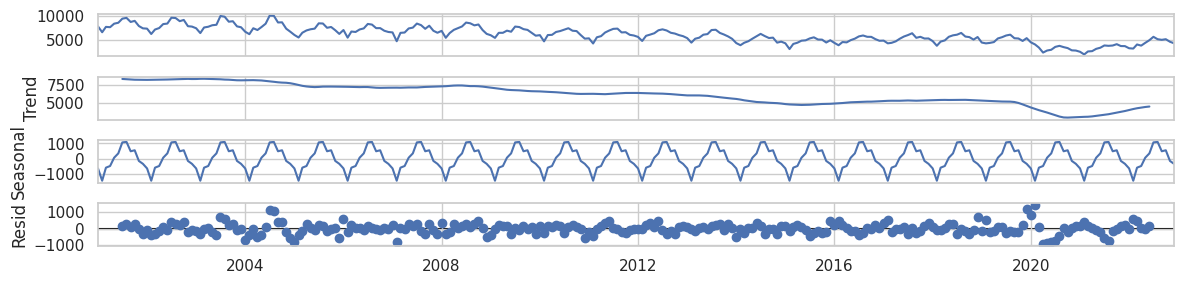

In [44]:
from statsmodels.tsa.seasonal import seasonal_decompose

seasonal_decompose(theft, period=12).plot()
plt.tight_layout()
plt.show()

### Decomposition — Theft

The Theft series shows a **strong, consistent yearly seasonality** (the seasonal
component repeats every 12 months with an amplitude of ~±1,000 crimes/month).
The trend declines over time with a clear COVID-19 dip around 2020. The residuals
are small and random, confirming a good decomposition.

**Conclusion:** seasonality is present, so we use a **seasonal SARIMA model (m = 12).**

## Stationarity Test — Theft
ADF test. If `sig/stationary?` is False → non-stationary → needs differencing.

In [45]:
get_adfuller_results(theft, label='Theft (original)')

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
Theft (original),-1.394004,13,250,0.585147,0.05,False


## Determine Differencing — Theft
Estimate regular differencing `d` (and check seasonal differencing `D`) using pmdarima.

In [46]:
from pmdarima.arima.utils import ndiffs, nsdiffs

d = ndiffs(theft, test='adf')
D = nsdiffs(theft, m=12, test='ocsb')
print(f"Suggested regular  differencing d = {d}")
print(f"Suggested seasonal differencing D = {D}")

Suggested regular  differencing d = 0
Suggested seasonal differencing D = 0


In [47]:
theft_stationary = theft.diff(1).diff(12).dropna()
get_adfuller_results(theft_stationary, label='Theft (differenced d=1, D=1)')

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
"Theft (differenced d=1, D=1)",-5.482292,12,238,0.000002,0.05,True


### Differencing Decision — Theft

The ADF test on the original series gives p = 0.585 → **non-stationary**.
Although `ndiffs`/`nsdiffs` suggested 0, the decomposition clearly shows a
declining trend and a strong 12-month seasonal cycle. We therefore apply:
- **d = 1** (regular differencing to remove the trend)
- **D = 1** (seasonal differencing, m=12, to remove the yearly cycle)

After differencing, the ADF test confirms the series is stationary.

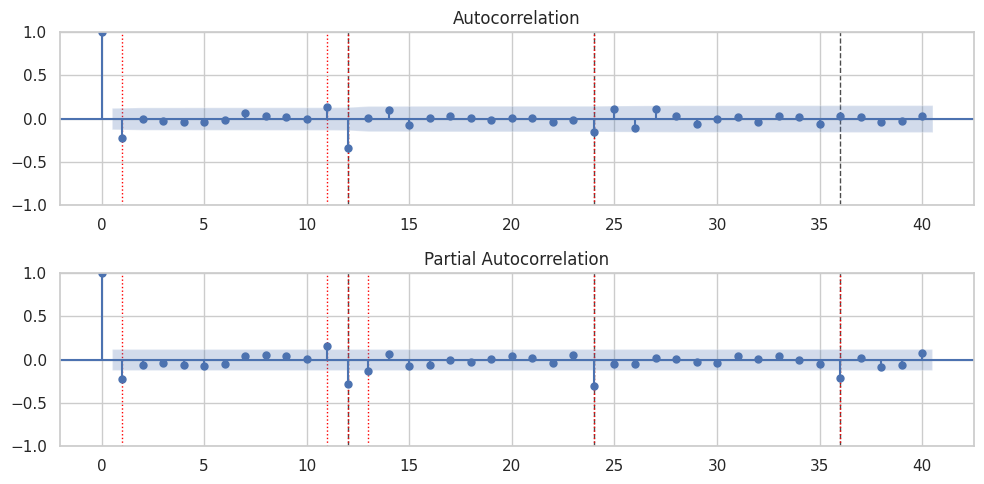

In [48]:
plot_acf_pacf(theft_stationary, nlags=40, annotate_sig=True, alpha=.05,
              annotate_seas=True, m=12)
plt.show()

### Reading the ACF/PACF — Theft (Initial Orders)

- **ACF:** significant spike at lag 1 → q = 1; strong significant spike at the
  seasonal lag 12 → Q = 1.
- **PACF:** significant spike at lag 1 → p = 1; significant spike at the seasonal
  lag 12 → P = 1.

**Initial manual model:** SARIMA(1, 1, 1)(1, 1, 1, 12)

## Train/Test Split — Theft
We hold out the **last 6 months** as the test set (we want to forecast 6 months).

In [49]:
train = theft.iloc[:-6]
test  = theft.iloc[-6:]

print("Train:", train.index.min().date(), "→", train.index.max().date(), "| n =", len(train))
print("Test :", test.index.min().date(),  "→", test.index.max().date(),  "| n =", len(test))

Train: 2001-01-01 → 2022-06-01 | n = 258
Test : 2022-07-01 → 2022-12-01 | n = 6


## Manual SARIMA Model — Theft
Fit SARIMA(1,1,1)(1,1,1,12) on the training data, forecast the test period,
and evaluate.

In [50]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

manual_model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit(disp=False)
manual_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  258
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1768.526
Date:                            Tue, 30 Jun 2026   AIC                           3547.053
Time:                                    16:39:33   BIC                           3564.559
Sample:                                01-01-2001   HQIC                          3554.103
                                     - 06-01-2022                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1936      0.228      0.849      0.396      -0.253       0.641
ma.L1         -0.4471      0.218     -2.051      0.040      -0.874      -0.020
ar.S.L12       0.1521      0.102      1.495      0.135      -0.047       0.352
ma.S.L12      -0.7498      0.068    -11.020      0.000      -0.883      -0.616
sigma2       1.04e+05   7089.188     14.675      0.000    9.01e+04    1.18e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                43.18
Prob(Q):                              0.83   Prob(JB):                         0.00
Heteroskedasticity (H):               1.18   Skew:                            -0.37
Prob(H) (two-sided):                  0.45   Kurtosis:                         4.92
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Manual SARIMA Summary — Theft

SARIMA(1,1,1)(1,1,1,12) — AIC = 3547.

- The **seasonal MA term `ma.S.L12` is highly significant (p = 0.000)** and the
  non-seasonal `ma.L1` is significant (p = 0.040), so the MA terms carry the model.
- The AR terms (`ar.L1`, `ar.S.L12`) are not significant, suggesting a simpler
  model may perform just as well — we will check this with `auto_arima`.
- **Ljung-Box Prob(Q) = 0.83** → residuals show no significant autocorrelation
  (the model captured the structure well).

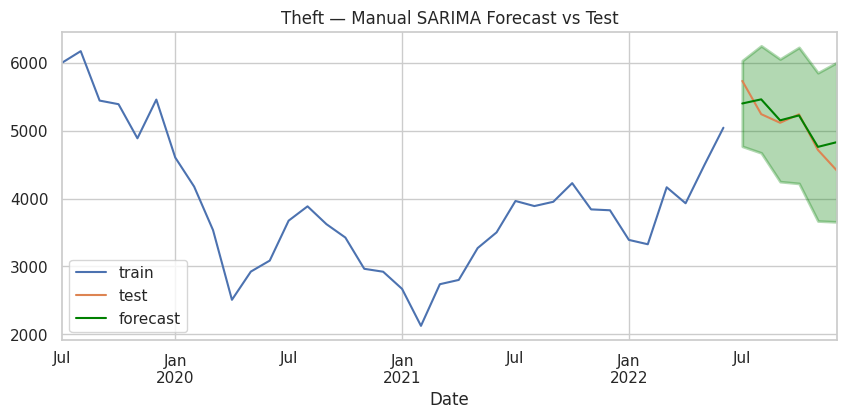

In [51]:
# Forecast the same length as the test set
forecast = manual_model.get_forecast(steps=len(test))
forecast_df = forecast.summary_frame()   # has: mean, mean_ci_lower, mean_ci_upper

plot_forecast(train, test, forecast_df, n_train_lags=36,
              title='Theft — Manual SARIMA Forecast vs Test')
plt.show()

### Manual SARIMA Forecast vs Test — Theft

The manual SARIMA(1,1,1)(1,1,1,12) model tracks the test period closely:

- The forecast (green) follows the actual test values (orange) well, correctly
  capturing the **downward movement** in the last quarter of 2022.
- All test points fall **within the 95% confidence interval** (shaded band),
  indicating the model's uncertainty is well-calibrated.
- This confirms the orders chosen from the ACF/PACF produce a reliable short-term
  forecast. Exact error metrics are reported below.

In [54]:
regression_metrics_ts(test, forecast_df['mean'], label='Theft — Manual SARIMA')

------------------------------------------------------------
Regression Metrics: Theft — Manual SARIMA
------------------------------------------------------------
- MAE = 177.658
- MSE = 56,126.128
- RMSE = 236.910
- R^2 = 0.682
- MAPE = 3.57%


### Manual SARIMA Metrics — Theft

| Metric | Value |
|---|---|
| MAE | 177.66 |
| RMSE | 236.91 |
| R² | 0.682 |
| MAPE | **3.57%** |

The manual model is highly accurate: a **MAPE of just 3.57%** means the forecast
is off by less than 4% on average. This is our baseline to beat with `auto_arima`.

## auto_arima — Theft
Let `pmdarima` search for the best orders automatically (seasonal, m=12),
then compare against the manual model.

In [55]:
auto_model = pm.auto_arima(train,
                           seasonal=True, m=12,
                           d=1, D=1,
                           trace=True,
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=inf, Time=4.22 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=3625.648, Time=0.07 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=3586.074, Time=0.97 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=3546.302, Time=1.25 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=3612.702, Time=0.14 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=3545.252, Time=2.35 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=3585.708, Time=0.89 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=3541.515, Time=2.49 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=3559.004, Time=0.92 sec
 ARIMA(0,1,1)(2,1,2)[12]             : AIC=3539.108, Time=7.82 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=3544.219, Time=5.78 sec
 ARIMA(0,1,0)(2,1,2)[12]             : AIC=3555.482, Time=2.35 sec
 ARIMA(1,1,1)(2,1,2)[12]             : AIC=3540.126, Time=7.30 sec
 ARIMA(0,1,2)(2,1,2)[12]             : AIC=3540.586, Time=9.09 sec
 ARIMA(1,1,0)(2,1,2)[12]

### auto_arima Result — Theft

`auto_arima` searched stepwise to minimize AIC and selected:

**Best model: ARIMA(0,1,1)(2,1,2)[12]** — AIC = 3539.11

Compared to the manual SARIMA(1,1,1)(1,1,1,12) (AIC = 3547.05), auto_arima found
a slightly lower AIC. Notably it **dropped the non-seasonal AR term** (p was 0),
matching what we saw in the manual model's summary (the `ar.L1` term was not
significant). We compare their test-set accuracy next.

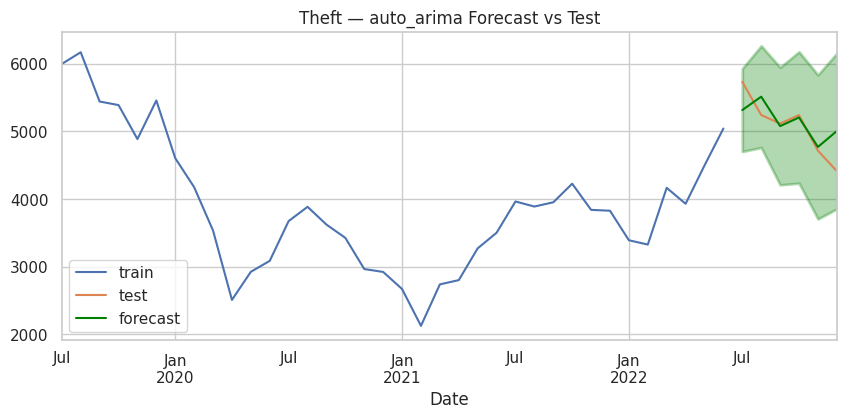

In [56]:
auto_fc, auto_ci = auto_model.predict(n_periods=len(test), return_conf_int=True)

auto_forecast_df = pd.DataFrame({
    'mean': auto_fc,
    'mean_ci_lower': auto_ci[:, 0],
    'mean_ci_upper': auto_ci[:, 1]
}, index=test.index)

plot_forecast(train, test, auto_forecast_df, n_train_lags=36,
              title='Theft — auto_arima Forecast vs Test')
plt.show()

### auto_arima Forecast vs Test — Theft

The auto_arima ARIMA(0,1,1)(2,1,2)[12] forecast (green) follows the actual test
values (orange) very closely — nearly overlapping through the middle of the test
window. All test points lie within the 95% confidence interval. Visually this
looks at least as good as the manual model; the metrics below confirm which is best.

In [57]:
regression_metrics_ts(test, auto_forecast_df['mean'], label='Theft — auto_arima')

------------------------------------------------------------
Regression Metrics: Theft — auto_arima
------------------------------------------------------------
- MAE = 234.559
- MSE = 100,846.999
- RMSE = 317.564
- R^2 = 0.429
- MAPE = 4.74%


## Model Selection — Theft

| Metric | Manual SARIMA(1,1,1)(1,1,1,12) | auto_arima ARIMA(0,1,1)(2,1,2)[12] |
|---|---|---|
| AIC | 3547.05 | 3539.11 |
| MAE | **177.66** | 234.56 |
| RMSE | **236.91** | 317.56 |
| R² | **0.682** | 0.429 |
| MAPE | **3.57%** | 4.74% |

**Chosen model: the manual SARIMA(1,1,1)(1,1,1,12).**

Although auto_arima achieved a slightly lower AIC (better fit on the training data),
the **manual model is more accurate on the held-out test set across every metric**
(MAE, RMSE, R², MAPE). AIC measures in-sample fit, while the test metrics measure
true forecasting accuracy on unseen data — so we prioritize the test metrics. The
more complex auto_arima model slightly overfit the training data and generalized
worse. We therefore use the manual model for the final 6-month forecast.

## Future Forecast (6 Months) — Theft
Refit the chosen manual model on the **entire** Theft series and forecast
6 months beyond the data (Jan–Jun 2023).

In [58]:
# Refit chosen model on the ENTIRE series
final_theft = SARIMAX(theft, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit(disp=False)

# Forecast 6 months into the future
future = final_theft.get_forecast(steps=6)
future_theft_df = future.summary_frame()

print(future_theft_df[['mean', 'mean_ci_lower', 'mean_ci_upper']].round(0))

y             mean  mean_ci_lower  mean_ci_upper
2023-01-01  4024.0         3394.0         4655.0
2023-02-01  3670.0         2884.0         4456.0
2023-03-01  4237.0         3339.0         5136.0
2023-04-01  4109.0         3114.0         5104.0
2023-05-01  4658.0         3575.0         5741.0
2023-06-01  5034.0         3871.0         6198.0


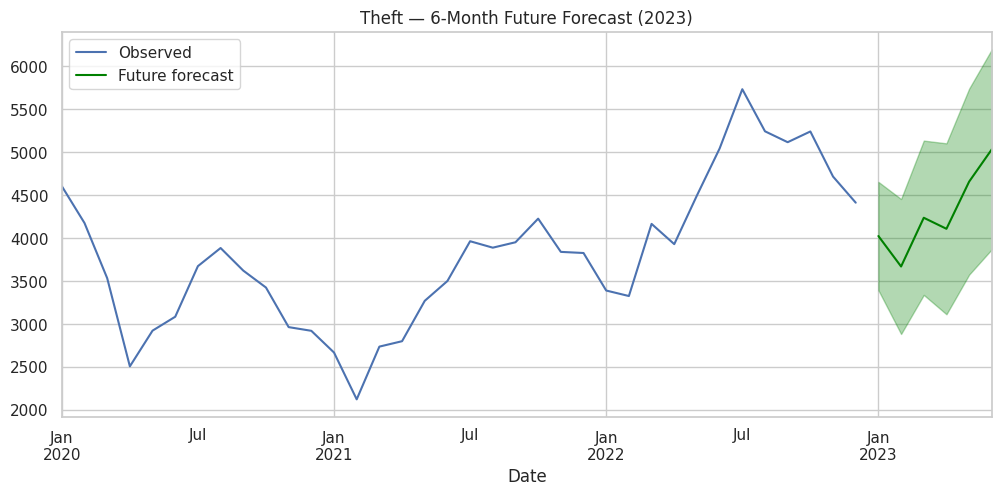

In [59]:
fig, ax = plt.subplots(figsize=(12, 5))
theft.iloc[-36:].plot(ax=ax, label='Observed')
future_theft_df['mean'].plot(ax=ax, color='green', label='Future forecast')
ax.fill_between(future_theft_df.index,
                future_theft_df['mean_ci_lower'],
                future_theft_df['mean_ci_upper'],
                color='green', alpha=0.3)
ax.set_title('Theft — 6-Month Future Forecast (2023)')
ax.legend()
plt.show()

### Theft — 6-Month Future Forecast (Jan–Jun 2023)

Using the chosen SARIMA(1,1,1)(1,1,1,12) model refit on the entire series, the
forecast (green) extends smoothly from the last observed value with no abrupt jump.
It reproduces the same **seasonal pattern** seen every year — a winter low around
February rising toward the summer — confirming the model captured both the trend
and the yearly seasonality. The shaded band is the 95% confidence interval, which
widens further into the future as uncertainty grows.

### Theft — Net Change & Percent Change

As required, we calculate the predicted **net change** (raw count) in Theft from
the start of the forecast (Jan 2023) to the end (Jun 2023), then convert it into a
**percent change**.

In [60]:
start_val = future_theft_df['mean'].iloc[0]
end_val   = future_theft_df['mean'].iloc[-1]
net_change = end_val - start_val
pct_change = (net_change / start_val) * 100

print(f"Theft — forecast start (Jan 2023): {start_val:,.0f}")
print(f"Theft — forecast end   (Jun 2023): {end_val:,.0f}")
print(f"Net change over forecast: {net_change:,.0f}")
print(f"Percent change: {pct_change:.2f}%")

Theft — forecast start (Jan 2023): 4,024
Theft — forecast end   (Jun 2023): 5,034
Net change over forecast: 1,010
Percent change: 25.10%


**Result — Theft:**
- Forecast start (Jan 2023): **4,024** crimes
- Forecast end (Jun 2023): **5,034** crimes
- **Net change:** +1,010 crimes
- **Percent change:** +25.10%

**Interpretation:** Theft is forecast to **rise by about 1,010 crimes (+25%)**
between January and June 2023. This increase reflects the normal seasonal climb
from the winter low toward the summer peak rather than a long-term surge — it is
consistent with the yearly pattern observed throughout the data. For resource
planning, this signals that **theft-related demand on police will grow heading into
summer 2023.**

# Forecasting — Battery

We repeat the full forecasting workflow for the second crime type, **Battery**:
decomposition → differencing → ACF/PACF → manual SARIMA → auto_arima → model
selection → 6-month future forecast.

## Decompose to Detect Seasonality — Battery
Check for a yearly cycle. A clear repeating pattern → use a seasonal model (m=12).

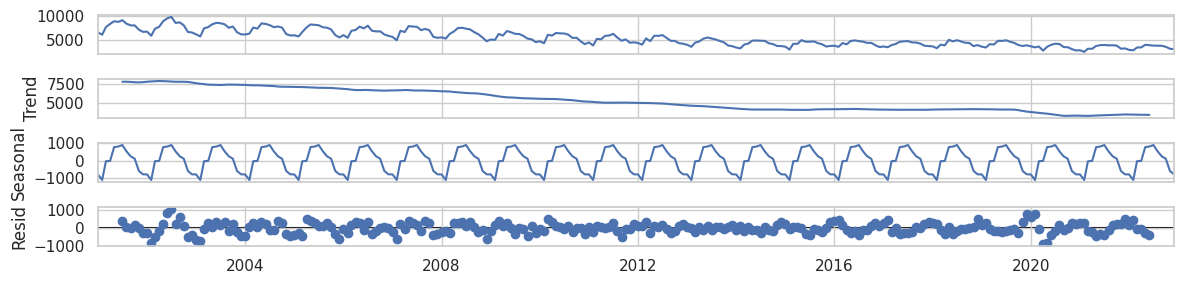

In [61]:
seasonal_decompose(battery, period=12).plot()
plt.tight_layout()
plt.show()

### Decomposition — Battery

Battery shows the same structure as Theft: a **strong, consistent 12-month
seasonality** (~±1,000 crimes/month) and a clear **downward trend** over the two
decades. Residuals are small and random, confirming a good decomposition.

**Conclusion:** seasonality is present → use a seasonal SARIMA model (m = 12).

## Stationarity & Differencing — Battery
ADF test on the original series, then check differencing. Based on the decomposition
(trend + strong seasonality) we expect d=1 and D=1, as with Theft.

In [62]:
get_adfuller_results(battery, label='Battery (original)')

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
Battery (original),-1.036949,15,248,0.739551,0.05,False


In [63]:
battery_stationary = battery.diff(1).diff(12).dropna()
get_adfuller_results(battery_stationary, label='Battery (differenced d=1, D=1)')

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
"Battery (differenced d=1, D=1)",-6.059534,12,238,0.0,0.05,True


### Differencing Decision — Battery

The original Battery series is non-stationary (ADF p = 0.74). After applying
**d = 1** (regular) and **D = 1** (seasonal, m=12) differencing, the ADF test
confirms stationarity (p = 0.0). Same configuration as Theft.

## ACF & PACF — Battery
Read AR (p) and MA (q) orders from the stationary series. Seasonal lines (m=12)
help identify seasonal orders P and Q.

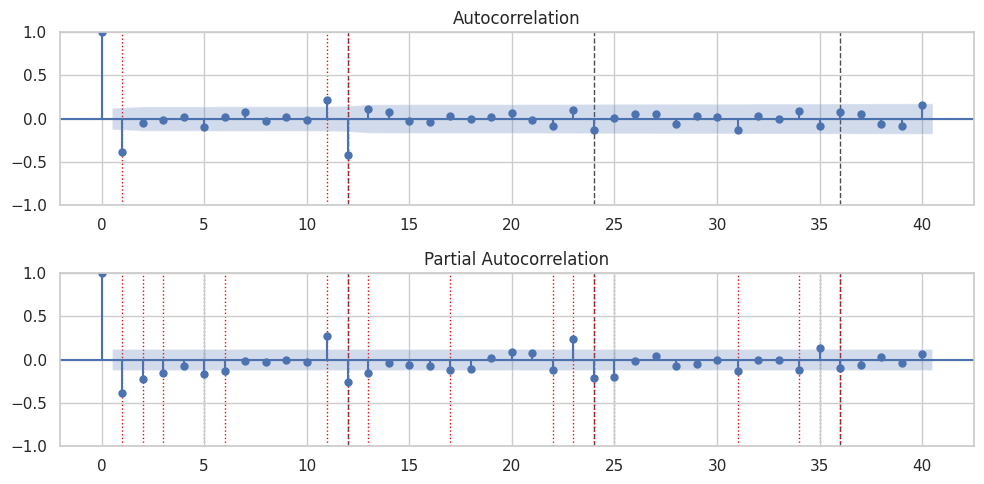

In [64]:
plot_acf_pacf(battery_stationary, nlags=40, annotate_sig=True, alpha=.05,
              annotate_seas=True, m=12)
plt.show()

### Reading the ACF/PACF — Battery (Initial Orders)

- **ACF:** significant spike at lag 1 → q = 1; strong significant spike at seasonal
  lag 12 → Q = 1.
- **PACF:** significant spike at lag 1 → p = 1; significant spike at seasonal
  lag 12 → P = 1.

**Initial manual model:** SARIMA(1, 1, 1)(1, 1, 1, 12) — same structure as Theft.

## Train/Test Split — Battery
Hold out the last 6 months as the test set.

In [65]:
train_b = battery.iloc[:-6]
test_b  = battery.iloc[-6:]

print("Train:", train_b.index.min().date(), "→", train_b.index.max().date(), "| n =", len(train_b))
print("Test :", test_b.index.min().date(),  "→", test_b.index.max().date(),  "| n =", len(test_b))

Train: 2001-01-01 → 2022-06-01 | n = 258
Test : 2022-07-01 → 2022-12-01 | n = 6


## Manual SARIMA Model — Battery
Fit SARIMA(1,1,1)(1,1,1,12), forecast the test period, and evaluate.

In [66]:
manual_model_b = SARIMAX(train_b, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit(disp=False)
manual_model_b.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  258
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1727.917
Date:                            Tue, 30 Jun 2026   AIC                           3465.833
Time:                                    17:02:09   BIC                           3483.340
Sample:                                01-01-2001   HQIC                          3472.883
                                     - 06-01-2022                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3565      0.090      3.979      0.000       0.181       0.532
ma.L1         -0.8335      0.057    -14.528      0.000      -0.946      -0.721
ar.S.L12      -0.0202      0.102     -0.199      0.842      -0.219       0.179
ma.S.L12      -0.6717      0.084     -7.962      0.000      -0.837      -0.506
sigma2      7.422e+04   6499.718     11.419      0.000    6.15e+04     8.7e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.24   Jarque-Bera (JB):                 3.56
Prob(Q):                              0.63   Prob(JB):                         0.17
Heteroskedasticity (H):               0.55   Skew:                            -0.24
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.34
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

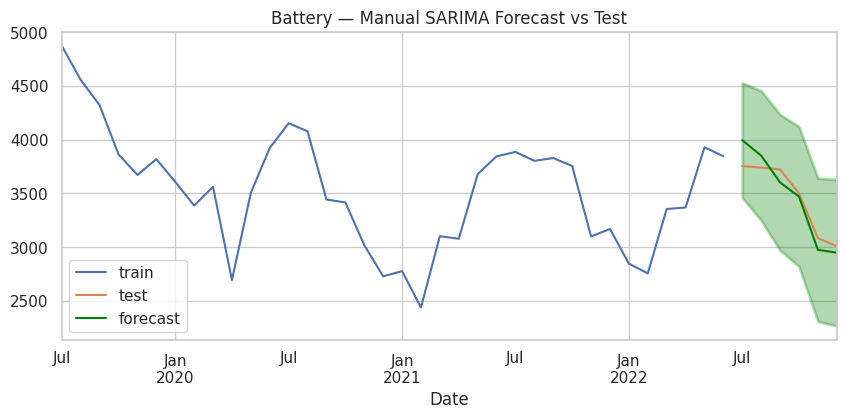

In [67]:
forecast_b = manual_model_b.get_forecast(steps=len(test_b))
forecast_b_df = forecast_b.summary_frame()

plot_forecast(train_b, test_b, forecast_b_df, n_train_lags=36,
              title='Battery — Manual SARIMA Forecast vs Test')
plt.show()

### Manual SARIMA Forecast vs Test — Battery

The manual SARIMA(1,1,1)(1,1,1,12) model tracks the Battery test period well:

- The forecast (green) follows the actual test values (orange) closely, correctly
  capturing the **downward movement** across the second half of 2022.
- All test points fall **within the 95% confidence interval** (shaded band), so the
  model's uncertainty is well-calibrated.
- The same orders that worked for Theft also produce a reliable short-term forecast
  for Battery. Exact error metrics are reported below.

In [68]:
regression_metrics_ts(test_b, forecast_b_df['mean'], label='Battery — Manual SARIMA')

------------------------------------------------------------
Regression Metrics: Battery — Manual SARIMA
------------------------------------------------------------
- MAE = 112.022
- MSE = 16,855.096
- RMSE = 129.827
- R^2 = 0.826
- MAPE = 3.17%


### Manual SARIMA Metrics — Battery

| Metric | Value |
|---|---|
| MAE | 112.02 |
| RMSE | 129.83 |
| R² | 0.826 |
| MAPE | **3.17%** |

Excellent accuracy — a **MAPE of 3.17%** (even better than Theft's 3.57%), with
R² = 0.83. This is our baseline to compare against auto_arima.

## auto_arima — Battery
Search for the best orders automatically (seasonal, m=12) and compare to the manual model.

In [69]:
auto_model_b = pm.auto_arima(train_b,
                             seasonal=True, m=12,
                             d=1, D=1,
                             trace=True,
                             error_action='ignore',
                             suppress_warnings=True,
                             stepwise=True)

print(auto_model_b.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=inf, Time=7.80 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=3614.112, Time=0.05 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=3533.778, Time=0.30 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=3471.597, Time=0.68 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=3555.792, Time=0.17 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=3473.480, Time=1.00 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=3473.387, Time=1.88 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=3510.779, Time=0.40 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=inf, Time=9.57 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=3513.877, Time=0.53 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=3463.890, Time=1.43 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=3552.483, Time=0.29 sec
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=3465.833, Time=1.47 sec
 ARIMA(1,1,1)(0,1,2)[12]             : AIC=3465.791, Time=2.98 sec
 ARIMA(1,1,1)(1,1,0)[12]     

### auto_arima Result — Battery

`auto_arima` searched stepwise to minimize AIC and selected:

**Best model: ARIMA(1,1,1)(0,1,1)[12]** — AIC = 3463.89

Compared to the manual SARIMA(1,1,1)(1,1,1,12), auto_arima dropped the seasonal AR
term (P = 0) while keeping the rest. We compare their test-set accuracy next to
decide which to use.

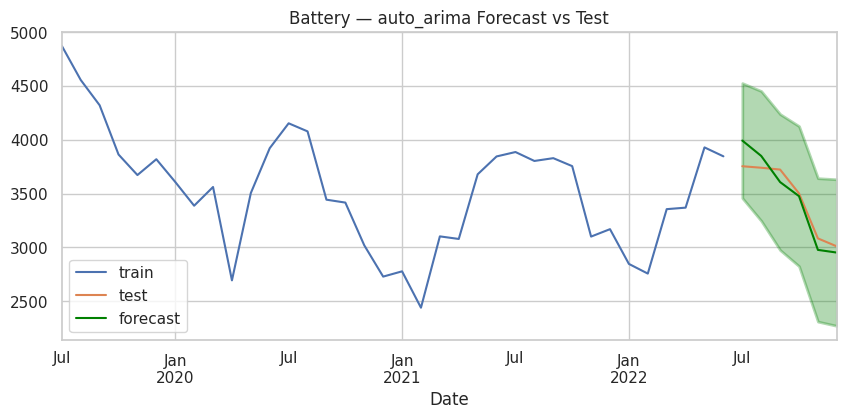

In [70]:
auto_fc_b, auto_ci_b = auto_model_b.predict(n_periods=len(test_b), return_conf_int=True)

auto_forecast_b_df = pd.DataFrame({
    'mean': auto_fc_b,
    'mean_ci_lower': auto_ci_b[:, 0],
    'mean_ci_upper': auto_ci_b[:, 1]
}, index=test_b.index)

plot_forecast(train_b, test_b, auto_forecast_b_df, n_train_lags=36,
              title='Battery — auto_arima Forecast vs Test')
plt.show()

### auto_arima Forecast vs Test — Battery

The auto_arima ARIMA(1,1,1)(0,1,1)[12] forecast (green) follows the actual test
values (orange) closely and captures the downward movement in late 2022. All test
points lie within the 95% confidence interval. Visually it performs similarly to
the manual model; the metrics below determine which is more accurate.

In [71]:
regression_metrics_ts(test_b, auto_forecast_b_df['mean'], label='Battery — auto_arima')

------------------------------------------------------------
Regression Metrics: Battery — auto_arima
------------------------------------------------------------
- MAE = 109.029
- MSE = 16,303.368
- RMSE = 127.685
- R^2 = 0.832
- MAPE = 3.09%


## Model Selection — Battery

| Metric | Manual SARIMA(1,1,1)(1,1,1,12) | auto_arima ARIMA(1,1,1)(0,1,1)[12] |
|---|---|---|
| AIC | — | 3463.89 |
| MAE | 112.02 | **109.03** |
| RMSE | 129.83 | **127.69** |
| R² | 0.826 | **0.832** |
| MAPE | 3.17% | **3.09%** |

**Chosen model: auto_arima ARIMA(1,1,1)(0,1,1)[12].**

For Battery, auto_arima outperforms the manual model on every test metric (by a
small margin) and is also simpler (it dropped the seasonal AR term). Unlike Theft —
where the manual model won — here the automated search found a better-generalizing
model, so we select it for the final forecast. Evaluating each crime independently
ensures the best model is used in each case.

## Future Forecast (6 Months) — Battery
Refit the chosen auto_arima model on the **entire** Battery series and forecast
6 months beyond the data (Jan–Jun 2023).

In [73]:
# Refit chosen auto_arima model on the ENTIRE Battery series
final_battery = pm.auto_arima(battery,
                              seasonal=True, m=12,
                              d=1, D=1,
                              error_action='ignore',
                              suppress_warnings=True,
                              stepwise=True)

In [74]:
# Forecast 6 months into the future
fb_fc, fb_ci = final_battery.predict(n_periods=6, return_conf_int=True)

In [76]:
future_idx = pd.date_range(battery.index[-1] + pd.offsets.MonthBegin(1),
                           periods=6, freq='MS')
future_battery_df = pd.DataFrame({
    'mean': fb_fc,
    'mean_ci_lower': fb_ci[:, 0],
    'mean_ci_upper': fb_ci[:, 1]
}, index=future_idx)

print(future_battery_df.round(0))

              mean  mean_ci_lower  mean_ci_upper
2023-01-01  2821.0         2292.0         3351.0
2023-02-01  2589.0         1991.0         3187.0
2023-03-01  3193.0         2567.0         3819.0
2023-04-01  3048.0         2404.0         3693.0
2023-05-01  3730.0         3070.0         4390.0
2023-06-01  3781.0         3107.0         4454.0


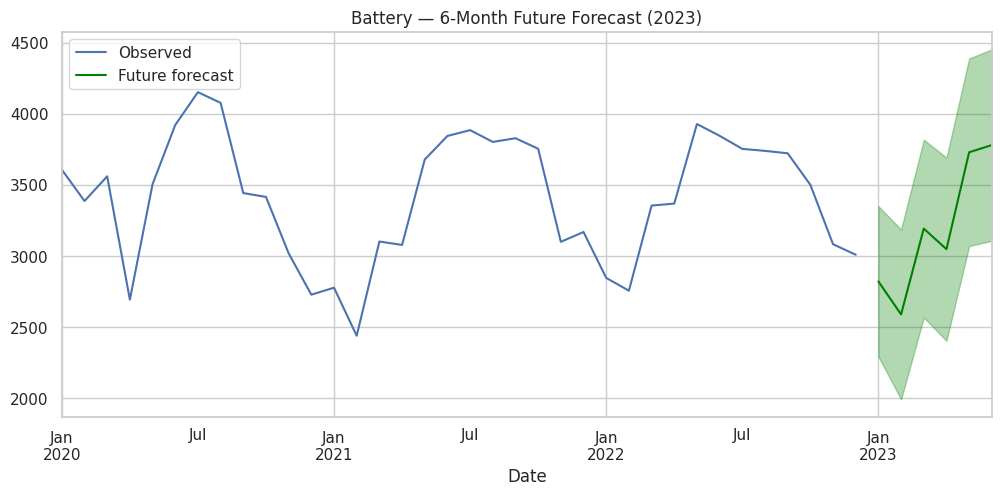

In [77]:
fig, ax = plt.subplots(figsize=(12, 5))
battery.iloc[-36:].plot(ax=ax, label='Observed')
future_battery_df['mean'].plot(ax=ax, color='green', label='Future forecast')
ax.fill_between(future_battery_df.index,
                future_battery_df['mean_ci_lower'],
                future_battery_df['mean_ci_upper'],
                color='green', alpha=0.3)
ax.set_title('Battery — 6-Month Future Forecast (2023)')
ax.legend()
plt.show()

### Battery — 6-Month Future Forecast (Jan–Jun 2023)

Using the chosen auto_arima ARIMA(1,1,1)(0,1,1)[12] model refit on the entire
series, the forecast (green) extends smoothly from the last observed value and
reproduces the expected **seasonal pattern** — a winter low around February rising
toward the summer. The shaded 95% confidence interval widens further into the
future as uncertainty grows, which is normal for longer-horizon forecasts.

In [78]:
start_b = future_battery_df['mean'].iloc[0]
end_b   = future_battery_df['mean'].iloc[-1]
net_b   = end_b - start_b
pct_b   = (net_b / start_b) * 100

print(f"Battery — forecast start (Jan 2023): {start_b:,.0f}")
print(f"Battery — forecast end   (Jun 2023): {end_b:,.0f}")
print(f"Net change over forecast: {net_b:,.0f}")
print(f"Percent change: {pct_b:.2f}%")

Battery — forecast start (Jan 2023): 2,821
Battery — forecast end   (Jun 2023): 3,781
Net change over forecast: 959
Percent change: 34.00%


### Battery — Net Change & Percent Change

- Forecast start (Jan 2023): **2,821** crimes
- Forecast end (Jun 2023): **3,781** crimes
- **Net change:** +959 crimes
- **Percent change:** +34.00%

**Interpretation:** Battery is forecast to rise by about 959 crimes (+34%) from
January to June 2023, following the normal seasonal climb from the winter low
toward summer.

# Final Evaluation — Theft vs Battery

| Metric (end of 6-month forecast) | Theft | Battery |
|---|---|---|
| Highest monthly count (Jun 2023) | **5,034** | 3,781 |
| Net change (raw) | **+1,010** | +959 |
| Percent change | +25.10% | **+34.00%** |

**1. Which crime is forecast to have the highest monthly count at the end of the
forecast?** → **Theft** (≈5,034 vs ≈3,781 for Battery).

**2. Which is forecast to have the highest net change?** → **Theft**
(+1,010 vs +959 crimes).

**3. Which is forecast to have the highest percent change?** → **Battery**
(+34.0% vs +25.1%). Battery grows faster *relatively* because it starts from a
lower January base.

# Final Recommendations

A single reporting-quality figure comparing the 6-month forecasts for both crimes,
followed by the recommendation to Chicago law enforcement.

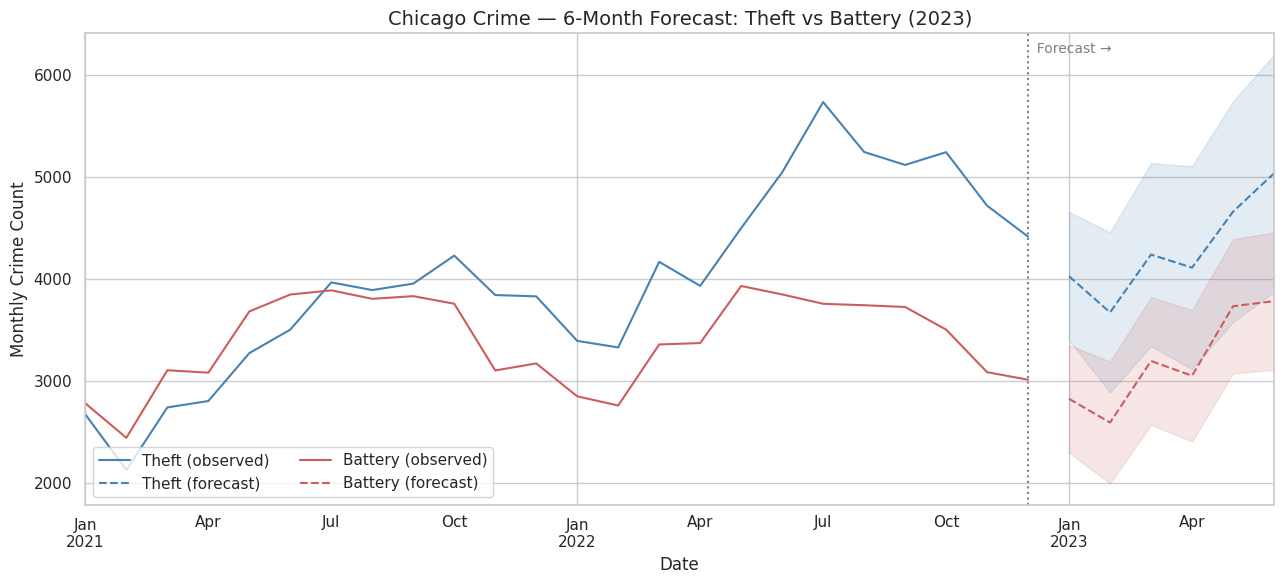

In [79]:
fig, ax = plt.subplots(figsize=(13, 6))

# --- Theft: observed + forecast ---
theft.iloc[-24:].plot(ax=ax, color='steelblue', label='Theft (observed)')
future_theft_df['mean'].plot(ax=ax, color='steelblue', linestyle='--', label='Theft (forecast)')
ax.fill_between(future_theft_df.index,
                future_theft_df['mean_ci_lower'], future_theft_df['mean_ci_upper'],
                color='steelblue', alpha=0.15)

# --- Battery: observed + forecast ---
battery.iloc[-24:].plot(ax=ax, color='indianred', label='Battery (observed)')
future_battery_df['mean'].plot(ax=ax, color='indianred', linestyle='--', label='Battery (forecast)')
ax.fill_between(future_battery_df.index,
                future_battery_df['mean_ci_lower'], future_battery_df['mean_ci_upper'],
                color='indianred', alpha=0.15)

# Line marking where the forecast begins
ax.axvline(theft.index[-1], color='gray', linestyle=':', lw=1.5)
ax.text(theft.index[-1], ax.get_ylim()[1]*0.97, '  Forecast →', color='gray', fontsize=10)

ax.set_title('Chicago Crime — 6-Month Forecast: Theft vs Battery (2023)', fontsize=14)
ax.set_ylabel('Monthly Crime Count')
ax.set_xlabel('Date')
ax.legend(loc='lower left', ncol=2)
plt.tight_layout()
plt.show()

### Forecast Summary — Theft vs Battery (2023)

This reporting-quality figure overlays the last two years of observed data (solid
lines) with the 6-month forecasts (dashed lines) and their 95% confidence intervals
(shaded bands), separated by the dotted line marking where the forecast begins.

**Key takeaways:**
- **Theft (blue)** stays the higher-volume crime throughout, ending at ~5,034/month
  in June 2023 vs ~3,781 for Battery.
- **Both crimes climb together** from the February winter low toward summer,
  reflecting the strong yearly seasonality found in the data.
- **Battery (red) rises faster relatively** (+34% vs +25%), narrowing the gap
  slightly by mid-2023.
- The widening shaded bands show forecast uncertainty growing with the horizon —
  normal and expected.

**Bottom line:** Chicago should scale police resources up into summer 2023,
prioritizing Theft by volume while monitoring Battery's faster growth rate.

## Recommendation to Stakeholders

**Both Theft and Battery are forecast to rise from winter into summer 2023, so
police resources should be scaled up heading into the warmer months.** Specific guidance:

1. **Prioritize Theft by volume.** Theft remains the larger burden, reaching ~5,034
   incidents/month by June 2023 vs ~3,781 for Battery. The bulk of additional patrol
   and investigative capacity should go toward theft prevention (retail / vehicle /
   property theft hotspots).

2. **Watch Battery's faster growth rate.** Although smaller in absolute numbers,
   Battery is forecast to grow faster (+34% vs +25% for Theft). Its quicker relative
   climb means it could demand disproportionately more resources if the trend holds —
   worth monitoring closely.

3. **Plan for the seasonal peak.** Both crimes follow a strong yearly cycle that
   troughs in February and rises toward summer. Staffing, overtime, and community
   programs should ramp up progressively from spring through summer, not stay flat.

4. **Confidence in the forecasts.** Both models are accurate on held-out data
   (MAPE ≈ 3.1–3.6%), making these projections a reliable basis for 6-month resource
   planning. Forecasts should be refreshed as 2023 actuals arrive to keep allocations
   aligned.